In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ✅ الحل هنا: استيراد AdamW من مكتبة torch بدلاً من transformers
from torch.optim import AdamW

from transformers import (
    AutoTokenizer, 
    AutoModel, 
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [10]:
CONFIG = {
    # Model
    'model_name': 'distilbert-base-uncased',
    'max_len': 128,
    
    # Training
    'batch_size': 32,
    'epochs': 5,
    'lr': 2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    
    # Loss
    'use_focal_loss': True,
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    
    # Bipolar-specific
    'bipolar_weight': 2.0,
    'bipolar_target': 1500,
    
    # Data
    'val_size': 0.2,
    'test_size': 0.2,
    
    # Other
    'random_seed': 42,
    'early_stopping_patience': 3,
}

torch.manual_seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])
random.seed(CONFIG['random_seed'])

In [11]:
FILES_CONFIG = [
    # Suicide & Stress
    {
        'path': r"C:\Users\MSI\Desktop\data\suicide and depression data\Suicide_Detection.csv",
        'type': 'suicide_detection',
        'cols': ('text', 'class')
    },
    {
        'path': r"C:\Users\MSI\Desktop\data\stress data\dreaddit-train.csv",
        'type': 'stress_dreaddit',
        'cols': ('text', 'label')
    },
    {
        'path': r"C:\Users\MSI\Desktop\data\stress data\dreaddit-test.csv",
        'type': 'stress_dreaddit',
        'cols': ('text', 'label')
    },
    
    # Original datasets
    {
        'path': r'Mental-Health-Twitter[1].csv',
        'type': 'twitter',
        'cols': ('post_text', 'label')
    },
    {
        'path': r"C:\Users\MSI\Desktop\data\يي\kaggle deppression\depression_dataset_reddit_cleaned.csv",
        'type': 'reddit',
        'cols': ('clean_text', 'is_depression')
    },
    {
        'path': r'counsel_chat2.csv',
        'type': 'counsel',
        'cols': ('questionText', 'topic')
    },
    {
        'path': r'Dataset.csv',
        'type': 'general',
        'cols': ('Context', 'Response')
    },
    
    # Symptoms datasets
    {
        'path': r"C:\Users\MSI\Desktop\data\يي\Mental Disorders Dataset\Mental disorder symptoms.xlsx",
        'type': 'symptoms_xl',
        'target': 'Disorder'
    },
    {
        'path': r"C:\Users\MSI\Desktop\data\يي\Mental Health Detection Dataset\Deepression.csv",
        'type': 'dep_state',
        'target': 'Depression State'
    },
    {
        'path': r"C:\Users\MSI\Desktop\data\يي\Mental-disorder\Dataset-Mental-Disorders.csv",
        'type': 'expert',
        'target': 'Expert Diagnose'
    },
    
    # Corpus
    {
        'path': r"C:\Users\MSI\Desktop\data\mental_health_corpus\mental_health.csv",
        'type': 'general_mental',
        'cols': ('text', 'label')
    }
]

def clean_text(text):
    """Clean and normalize text"""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_label(label):
    """Normalize labels"""
    lbl = str(label).lower().strip()
    
    if any(x in lbl for x in ['depress', 'sad', 'hopeless', 'lonely', 'down']):
        return 'Depression'
    if any(x in lbl for x in ['anxi', 'stress', 'nervous', 'panic', 'worry']):
        return 'Anxiety/Stress'
    if any(x in lbl for x in ['suicid', 'kill my', 'die', 'end my life']):
        return 'Suicide'
    if 'bipolar' in lbl or 'manic' in lbl:
        return 'Bipolar'
    if any(x in lbl for x in ['ptsd', 'trauma', 'flashback', 'abuse']):
        return 'PTSD'
    if lbl in ['normal', 'none', '0', 'no', 'control', 'healthy']:
        return 'Normal'
    
    return None

def symptoms_to_text(symptoms):
    """Convert symptoms to natural text"""
    if not symptoms:
        return ""
    if len(symptoms) == 1:
        return f"I have been experiencing {symptoms[0]} recently."
    elif len(symptoms) == 2:
        return f"I am struggling with {symptoms[0]} and {symptoms[1]}."
    else:
        first_part = ", ".join(symptoms[:-1])
        return f"I have symptoms including {first_part}, and {symptoms[-1]}."

def load_all_datasets(configs, max_per_file=15000):
    """Load all 12 datasets"""
    print("Loading datasets...")
    all_data = []
    
    for config in configs:
        fpath = config['path']
        ftype = config['type']
        
        # Check file existence
        if not os.path.exists(fpath):
            fpath = os.path.basename(fpath)
            if not os.path.exists(fpath):
                print(f" Not found: {os.path.basename(config['path'])}")
                continue
        
        try:
            # Load file
            if fpath.endswith('.xlsx'):
                df = pd.read_excel(fpath)
            else:
                try:
                    df = pd.read_csv(fpath, encoding='utf-8')
                except:
                    df = pd.read_csv(fpath, encoding='latin-1')
            
            print(f" {os.path.basename(fpath)}: {len(df)} rows")
            temp_list = []
            
            # Process by type
            if ftype == 'suicide_detection':
                subset = df.sample(min(len(df), max_per_file), random_state=42)
                for _, row in subset.iterrows():
                    lbl = 'Suicide' if row['class'] == 'suicide' else 'Normal'
                    temp_list.append({'text': row['text'], 'label': lbl})
            
            elif ftype == 'stress_dreaddit':
                has_subreddit = 'subreddit' in df.columns
                for _, row in df.iterrows():
                    if pd.notna(row['text']):
                        if row['label'] == 0:
                            lbl = 'Normal'
                        else:
                            lbl = 'Anxiety/Stress'
                            
                            # Smart subreddit mapping
                            if has_subreddit and pd.notna(row['subreddit']):
                                sub = str(row['subreddit']).lower()
                                if any(x in sub for x in ['ptsd', 'abuse', 'domestic']):
                                    lbl = 'PTSD'
                                elif 'bipolar' in sub:
                                    lbl = 'Bipolar'
                        
                        temp_list.append({'text': row['text'], 'label': lbl})
            
            elif ftype in ['twitter', 'reddit', 'general_mental']:
                txt_col, lbl_col = config['cols']
                for _, row in df.iterrows():
                    if pd.notna(row[txt_col]):
                        val = str(row[lbl_col]).lower()
                        lbl = 'Depression' if val in ['1', '1.0', 'true'] else 'Normal'
                        temp_list.append({'text': row[txt_col], 'label': lbl})
            
            elif ftype == 'counsel':
                txt_col, lbl_col = config['cols']
                for _, row in df.iterrows():
                    if pd.notna(row[txt_col]) and pd.notna(row[lbl_col]):
                        mapped = normalize_label(row[lbl_col])
                        if mapped:
                            temp_list.append({'text': row[txt_col], 'label': mapped})
            
            elif ftype == 'general':
                txt_col = config['cols'][0]
                for _, row in df.iterrows():
                    txt = str(row[txt_col])
                    if 'Response' in df.columns and pd.notna(row['Response']):
                        txt += ' ' + str(row['Response'])
                    
                    txt_lower = txt.lower()
                    lbl = 'Normal'
                    if any(w in txt_lower for w in ['sad', 'depress', 'hopeless']):
                        lbl = 'Depression'
                    elif any(w in txt_lower for w in ['anxi', 'panic', 'worry']):
                        lbl = 'Anxiety/Stress'
                    elif 'suicid' in txt_lower:
                        lbl = 'Suicide'
                    
                    temp_list.append({'text': txt, 'label': lbl})
            
            elif ftype in ['symptoms_xl', 'expert', 'dep_state']:
                target_col = config['target']
                actual_target = next((c for c in df.columns if target_col.lower() in c.lower()), None)
                
                if actual_target:
                    symptom_cols = [c for c in df.columns 
                                   if c != actual_target 
                                   and 'id' not in c.lower() 
                                   and 'unnamed' not in c.lower()]
                    
                    for _, row in df.iterrows():
                        symptoms = [
                            c.replace('_', ' ') 
                            for c in symptom_cols 
                            if str(row[c]).lower() in ['yes', '1', 'true', 'present']
                        ]
                        
                        if symptoms:
                            mapped = normalize_label(row[actual_target])
                            if mapped:
                                temp_list.append({
                                    'text': symptoms_to_text(symptoms),
                                    'label': mapped
                                })
            
            all_data.extend(temp_list)
            print(f"      → Added {len(temp_list)} samples")
        
        except Exception as e:
            print(f" Error: {e}")
    
    return pd.DataFrame(all_data)


In [12]:
def augment_bipolar(text, method='synonym'):
    """Bipolar-specific augmentation"""
    words = text.split()
    if len(words) < 3:
        return text
    
    if method == 'synonym':
        replacements = {
            'mood': ['emotional state', 'feelings'],
            'swings': ['shifts', 'changes'],
            'manic': ['energetic', 'hyperactive'],
            'depressed': ['down', 'low'],
        }
        return ' '.join([random.choice(replacements.get(w, [w])) for w in words])
    
    elif method == 'context':
        contexts = [" and it changes rapidly", " with extreme mood swings", " affecting my stability"]
        return text + random.choice(contexts)
    
    elif method == 'insertion':
        intensifiers = ['extreme', 'severe', 'rapid']
        pos = random.randint(0, len(words))
        words.insert(pos, random.choice(intensifiers))
        return ' '.join(words)
    
    else:
        if len(words) > 3:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
        return ' '.join(words)

def augment_general(text, method='synonym'):
    """General augmentation"""
    words = text.split()
    if len(words) < 3:
        return text
    
    if method == 'synonym':
        replacements = {
            'sad': ['unhappy', 'down'],
            'happy': ['good', 'fine'],
            'anxious': ['worried', 'nervous'],
            'tired': ['exhausted', 'drained'],
        }
        return ' '.join([random.choice(replacements.get(w, [w])) for w in words])
    
    elif method == 'deletion':
        if len(words) > 5:
            keep = random.sample(range(len(words)), k=int(len(words)*0.8))
            return ' '.join([words[i] for i in sorted(keep)])
        return text
    
    elif method == 'swap':
        if len(words) > 3:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
        return ' '.join(words)
    
    else:
        fillers = ['really', 'very', 'extremely']
        pos = random.randint(0, len(words))
        words.insert(pos, random.choice(fillers))
        return ' '.join(words)

def generate_synthetic_bipolar(n_samples=500):
    """Generate synthetic Bipolar samples"""
    templates = [
        "my mood swings between {} and {}",
        "i experience {} followed by {}",
        "my emotions {} with {} episodes",
        "i have periods of {} then {}",
    ]
    
    manic = ['high energy', 'euphoria', 'racing thoughts', 'impulsiveness']
    depressive = ['depression', 'hopelessness', 'fatigue', 'worthlessness']
    
    samples = []
    for i in range(n_samples):
        template = random.choice(templates)
        text = template.format(random.choice(manic), random.choice(depressive))
        samples.append({'text': text, 'label': 'Bipolar'})
    
    return pd.DataFrame(samples)

def balance_data_smart(df, target_bipolar=1500):
    """Smart balancing with Bipolar focus"""
    print(" Smart Balancing...")
    
    counts = df['label'].value_counts()
    print(" Before:")
    for label, count in counts.items():
        print(f"   {label:20s}: {count:5d}")
    
    balanced_dfs = []
    
    for label in df['label'].unique():
        df_label = df[df['label'] == label]
        current = len(df_label)
        
        # Special: Bipolar
        if label == 'Bipolar':
            print(f"Bipolar Special Handling:")
            
            # Synthetic
            n_synthetic = min(500, target_bipolar - current)
            if n_synthetic > 0:
                synthetic_df = generate_synthetic_bipolar(n_synthetic)
                print(f"   → Generated {n_synthetic} synthetic samples")
            else:
                synthetic_df = pd.DataFrame()
            
            # Augment
            needed = target_bipolar - current - n_synthetic
            if needed > 0:
                augmented = []
                methods = ['synonym', 'context', 'insertion', 'swap']
                for i in range(needed):
                    sample = df_label.sample(1).iloc[0]
                    aug_text = augment_bipolar(sample['text'], methods[i % len(methods)])
                    augmented.append({'text': aug_text, 'label': 'Bipolar'})
                augmented_df = pd.DataFrame(augmented)
                print(f"   → Augmented {needed} samples")
            else:
                augmented_df = pd.DataFrame()
            
            all_bipolar = pd.concat([df_label, synthetic_df, augmented_df], ignore_index=True)
            balanced_dfs.append(all_bipolar)
            print(f" Total: {len(all_bipolar)}")
            continue
        
        # Normal handling
        if current < 500:
            target = min(2000, current * 5)
        elif current < 2000:
            target = 2500
        elif current < 5000:
            target = current
        else:
            target = 3000
        
        if current < target:
            needed = target - current
            augmented = []
            methods = ['synonym', 'deletion', 'swap', 'insertion']
            for i in range(needed):
                sample = df_label.sample(1).iloc[0]
                aug_text = augment_general(sample['text'], methods[i % len(methods)])
                augmented.append({'text': aug_text, 'label': label})
            
            balanced_dfs.append(pd.concat([df_label, pd.DataFrame(augmented)], ignore_index=True))
            print(f"   {label:20s}: {current:5d} → {target:5d}")
        
        elif current > target:
            balanced_dfs.append(df_label.sample(target, random_state=42))
            print(f"   {label:20s}: {current:5d} → {target:5d}")
        
        else:
            balanced_dfs.append(df_label)
            print(f"   {label:20s}: {current:5d} (kept)")
    
    df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f" Balanced: {len(df_balanced)} samples")
    print("After:")
    for label, count in df_balanced['label'].value_counts().items():
        print(f"   {label:20s}: {count:5d}")
    
    return df_balanced


In [21]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class MentalHealthClassifier(nn.Module):
    def __init__(self, model_name, n_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, n_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]
        dropped = self.drop(pooled)
        return self.fc(dropped)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.class_weights = class_weights
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [22]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def eval_epoch(model, dataloader, criterion, device, class_names):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    
    return {
        'loss': total_loss / len(dataloader),
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_per_class': dict(zip(class_names, f1_per_class)),
        'predictions': all_preds,
        'labels': all_labels
    }

In [23]:
df_raw = load_all_datasets(FILES_CONFIG)

print(f" Total samples loaded: {len(df_raw)}")

# Clean
print("Cleaning text...")
df_raw['text'] = df_raw['text'].apply(clean_text)
df_raw = df_raw[df_raw['text'].str.len() > 10]

# Normalize labels
label_map = {'Suicidal': 'Suicide', 'Stress': 'Anxiety/Stress', 'Trauma': 'PTSD'}
df_raw['label'] = df_raw['label'].replace(label_map)

# Filter valid classes
valid_classes = ['Normal', 'Depression', 'Suicide', 'Anxiety/Stress', 'Bipolar', 'PTSD']
df_clean = df_raw[df_raw['label'].isin(valid_classes)].copy()

print(f" After cleaning: {len(df_clean)} samples")
print(" Initial distribution:")
for label, count in df_clean['label'].value_counts().items():
    print(f"   {label:20s}: {count:6d}")

Loading datasets...
 Suicide_Detection.csv: 232074 rows
      → Added 15000 samples
 dreaddit-train.csv: 2838 rows
      → Added 2838 samples
 dreaddit-test.csv: 715 rows
      → Added 715 samples
 Mental-Health-Twitter[1].csv: 20000 rows
      → Added 20000 samples
 depression_dataset_reddit_cleaned.csv: 7731 rows
      → Added 7731 samples
 counsel_chat2.csv: 2129 rows
      → Added 687 samples
 Dataset.csv: 3512 rows
      → Added 3512 samples
 Mental disorder symptoms.xlsx: 637 rows
      → Added 89 samples
 Deepression.csv: 813 rows
      → Added 0 samples
 Dataset-Mental-Disorders.csv: 120 rows
      → Added 119 samples
 mental_health.csv: 27977 rows
      → Added 27977 samples
 Total samples loaded: 78668
Cleaning text...
 After cleaning: 77906 samples
 Initial distribution:
   Normal              :  39168
   Depression          :  28459
   Suicide             :   7492
   Anxiety/Stress      :   1733
   PTSD                :    952
   Bipolar             :    102


In [24]:
df_temp, df_test = train_test_split(
    df_clean,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_seed'],
    stratify=df_clean['label']
)

df_train, df_val = train_test_split(
    df_temp,
    test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
    random_state=CONFIG['random_seed'],
    stratify=df_temp['label']
)

print(f"Train: {len(df_train)} ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"Val:   {len(df_val)} ({len(df_val)/len(df_clean)*100:.1f}%)")
print(f"Test:  {len(df_test)} ({len(df_test)/len(df_clean)*100:.1f}%)")

Train: 46743 (60.0%)
Val:   15581 (20.0%)
Test:  15582 (20.0%)


In [25]:
# Balance TRAIN only
df_train_balanced = balance_data_smart(df_train, target_bipolar=CONFIG['bipolar_target'])

# Save datasets
df_train_balanced.to_csv('train_balanced.csv', index=False)
df_val.to_csv('val.csv', index=False)
df_test.to_csv('test.csv', index=False)
print(" Saved: train_balanced.csv, val.csv, test.csv")

 Smart Balancing...
 Before:
   Normal              : 23500
   Depression          : 17075
   Suicide             :  4495
   Anxiety/Stress      :  1039
   PTSD                :   572
   Bipolar             :    62
   Normal              : 23500 →  3000
   Depression          : 17075 →  3000
   PTSD                :   572 →  2500
   Anxiety/Stress      :  1039 →  2500
   Suicide             :  4495 (kept)
Bipolar Special Handling:
   → Generated 500 synthetic samples
   → Augmented 938 samples
 Total: 1500
 Balanced: 16995 samples
After:
   Suicide             :  4495
   Depression          :  3000
   Normal              :  3000
   PTSD                :  2500
   Anxiety/Stress      :  2500
   Bipolar             :  1500
 Saved: train_balanced.csv, val.csv, test.csv


In [26]:
# Encode labels
le = LabelEncoder()
le.fit(df_clean['label'])

y_train = le.transform(df_train_balanced['label'])
y_val = le.transform(df_val['label'])
y_test = le.transform(df_test['label'])

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

# Datasets
train_dataset = MentalHealthDataset(df_train_balanced['text'].values, y_train, tokenizer, CONFIG['max_len'])
val_dataset = MentalHealthDataset(df_val['text'].values, y_val, tokenizer, CONFIG['max_len'])
test_dataset = MentalHealthDataset(df_test['text'].values, y_test, tokenizer, CONFIG['max_len'])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], num_workers=0)

# Model
model = MentalHealthClassifier(CONFIG['model_name'], len(le.classes_), dropout=0.3).to(device)
print(f" Model: {sum(p.numel() for p in model.parameters()):,} parameters")

# Class weights
class_weights = torch.ones(len(le.classes_)).to(device)
bipolar_idx = list(le.classes_).index('Bipolar')
class_weights[bipolar_idx] = CONFIG['bipolar_weight']

# Loss & Optimizer
if CONFIG['use_focal_loss']:
    criterion = FocalLoss(CONFIG['focal_alpha'], CONFIG['focal_gamma'], class_weights)
    print(" Using Focal Loss")
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

total_steps = len(train_loader) * CONFIG['epochs']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * CONFIG['warmup_ratio']),
    num_training_steps=total_steps
)

 Model: 66,367,494 parameters
 Using Focal Loss


In [27]:
best_f1 = 0
patience_counter = 0

for epoch in range(CONFIG['epochs']):
    print(f"Epoch {epoch+1}/{CONFIG['epochs']}")
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    val_metrics = eval_epoch(model, val_loader, criterion, device, le.classes_)
    
    print(f"Results:")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Val Loss:   {val_metrics['loss']:.4f}")
    print(f"   Val F1:     {val_metrics['f1_macro']:.4f}")
    
    print(f"Per-Class F1:")
    for cls, f1 in val_metrics['f1_per_class'].items():
        print(f"   {cls:20s}: {f1:.4f}")
    
    if val_metrics['f1_macro'] > best_f1:
        best_f1 = val_metrics['f1_macro']
        torch.save({
            'model_state_dict': model.state_dict(),
            'label_encoder': le,
            'config': CONFIG
        }, 'best_model.pt')
        print(f" Saved! F1: {best_f1:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['early_stopping_patience']:
            print(" Early stopping!")
            break

Epoch 1/5


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 487/487 [30:44<00:00,  3.79s/it]


Results:
   Train Loss: 0.1192
   Val Loss:   0.0616
   Val F1:     0.6623
Per-Class F1:
   Anxiety/Stress      : 0.3754
   Bipolar             : 0.6780
   Depression          : 0.7918
   Normal              : 0.7882
   PTSD                : 0.4887
   Suicide             : 0.8516
 Saved! F1: 0.6623
Epoch 2/5


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 487/487 [30:45<00:00,  3.79s/it]


Results:
   Train Loss: 0.0306
   Val Loss:   0.0405
   Val F1:     0.7616
Per-Class F1:
   Anxiety/Stress      : 0.5851
   Bipolar             : 0.8511
   Depression          : 0.8226
   Normal              : 0.8291
   PTSD                : 0.6027
   Suicide             : 0.8791
 Saved! F1: 0.7616
Epoch 3/5


...

Results:
   Train Loss: 0.0151
   Val Loss:   0.0380
   Val F1:     0.7865
Per-Class F1:
   Anxiety/Stress      : 0.5738
   Bipolar             : 0.9500
   Depression          : 0.8263
   Normal              : 0.8568
   PTSD                : 0.6050
   Suicide             : 0.9073
 Saved! F1: 0.7865
Epoch 4/5


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 487/487 [30:42<00:00,  3.78s/it]


Results:
   Train Loss: 0.0086
   Val Loss:   0.0472
   Val F1:     0.7515
Per-Class F1:
   Anxiety/Stress      : 0.5626
   Bipolar             : 0.8163
   Depression          : 0.8354
   Normal              : 0.8348
   PTSD                : 0.5906
   Suicide             : 0.8690
Epoch 5/5


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 487/487 [30:46<00:00,  3.79s/it]

Results:
   Train Loss: 0.0058
   Val Loss:   0.0466
   Val F1:     0.7624
Per-Class F1:
   Anxiety/Stress      : 0.5787
   Bipolar             : 0.8444
   Depression          : 0.8366
   Normal              : 0.8413
   PTSD                : 0.6038
   Suicide             : 0.8695


In [28]:
checkpoint = torch.load('best_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])

test_metrics = eval_epoch(model, test_loader, criterion, device, le.classes_)

print(f"Test Results:")
print(f"   F1 (macro):    {test_metrics['f1_macro']:.4f}")
print(f"   F1 (weighted): {test_metrics['f1_weighted']:.4f}")

print(f" Per-Class F1:")
for cls, f1 in test_metrics['f1_per_class'].items():
    print(f"  {cls:20s}: {f1:.4f}")

print(" Classification Report:")
print(classification_report(test_metrics['labels'], test_metrics['predictions'], target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
print(" Saved confusion_matrix.png")
print(" TRAINING COMPLETE!")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL sklearn.preprocessing._label.LabelEncoder was not an allowed global by default. Please use `torch.serialization.add_safe_globals([sklearn.preprocessing._label.LabelEncoder])` or the `torch.serialization.safe_globals([sklearn.preprocessing._label.LabelEncoder])` context manager to allowlist this global if you trust this class/function.

Check the d

 Loading best model...


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 487/487 [31:02<00:00,  3.82s/it]


Test Results:
   F1 (macro):    0.7681
   F1 (weighted): 0.8433

📊 Per-Class F1:
   Anxiety/Stress      : 0.5746
   Bipolar             : 0.8333
   Depression          : 0.8278
   Normal              : 0.8599
   PTSD                : 0.6056
   Suicide             : 0.9076
 Classification Report:
                precision    recall  f1-score   support

Anxiety/Stress       0.47      0.75      0.57       347
       Bipolar       0.71      1.00      0.83        20
    Depression       0.87      0.79      0.83      5692
        Normal       0.85      0.87      0.86      7834
          PTSD       0.59      0.63      0.61       190
       Suicide       0.88      0.93      0.91      1499

      accuracy                           0.84     15582
     macro avg       0.73      0.83      0.77     15582
  weighted avg       0.85      0.84      0.84     15582

 Saved confusion_matrix.png
 TRAINING COMPLETE!


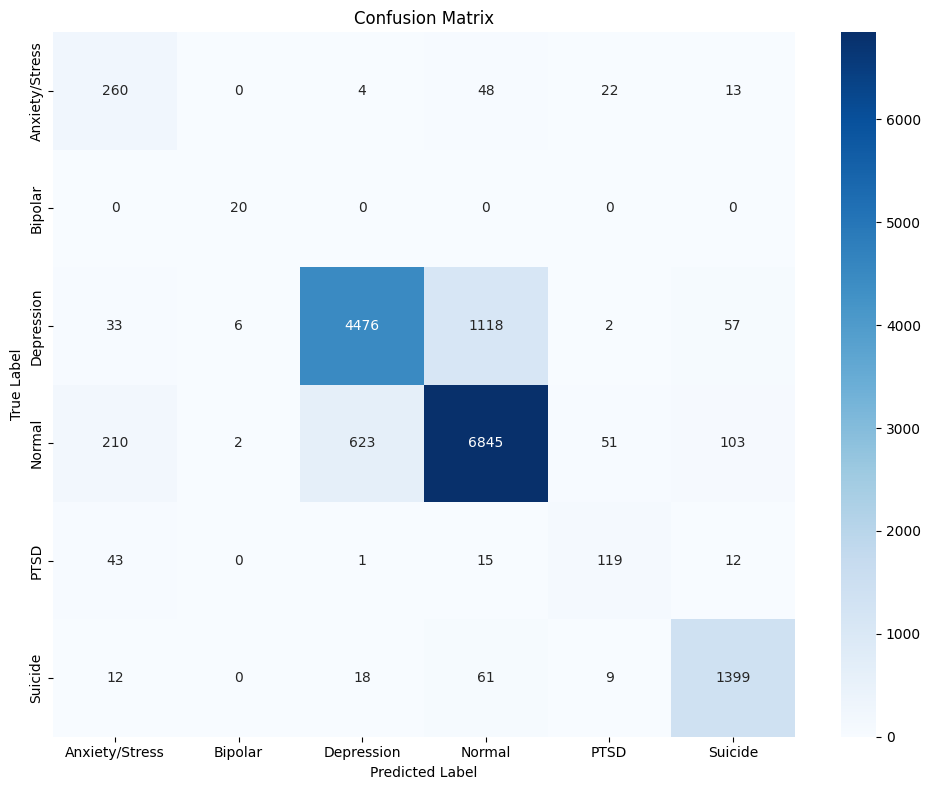

In [29]:
# ==============================================================================
# FINAL EVALUATION (Fixed for PyTorch 2.6+)
# ==============================================================================

# 1. تحميل الموديل مع السماح بالملفات الإضافية (LabelEncoder)
print(" Loading best model...")
checkpoint = torch.load('best_model.pt', weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

# استرجاع الـ LabelEncoder المحفوظ عشان نستخدم نفس الترتيب
le = checkpoint['label_encoder']

# 2. التقييم
test_metrics = eval_epoch(model, test_loader, criterion, device, le.classes_)

print(f"Test Results:")
print(f"   F1 (macro):    {test_metrics['f1_macro']:.4f}")
print(f"   F1 (weighted): {test_metrics['f1_weighted']:.4f}")

print(f" Per-Class F1:")
for cls, f1 in test_metrics['f1_per_class'].items():
    print(f"   {cls:20s}: {f1:.4f}")

print(" Classification Report:")
print(classification_report(test_metrics['labels'], test_metrics['predictions'], target_names=le.classes_))

# 3. رسم مصفوفة التشتت (Confusion Matrix)
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
print(" Saved confusion_matrix.png")
print(" TRAINING COMPLETE!")